## Minimal YOLOX OpenVINO inference example.


In [1]:
# YOLOX OpenVINO Inference Demo - Jupyter Notebook

## 1. Install Required Packages (Run once)
# Uncomment and run if packages are not installed
# !pip install openvino opencv-python numpy matplotlib



In [2]:
## 2. Import Libraries
import sys
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display
from openvino import Core

# Enable inline plotting
%matplotlib inline


In [3]:

## 3. COCO Class Names
COCO_CLASSES = (
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat",
    "traffic light", "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat",
    "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra", "giraffe", "backpack",
    "umbrella", "handbag", "tie", "suitcase", "frisbee", "skis", "snowboard", "sports ball",
    "kite", "baseball bat", "baseball glove", "skateboard", "surfboard", "tennis racket",
    "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair",
    "couch", "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote",
    "keyboard", "cell phone", "microwave", "oven", "toaster", "sink", "refrigerator", "book",
    "clock", "vase", "scissors", "teddy bear", "hair drier", "toothbrush",
)

In [4]:
## 4. Helper Functions

def preprocess(img, input_size=(640, 640)):
    """Preprocess image for YOLOX inference (letterbox + normalize)."""
    if len(img.shape) == 3:
        padded_img = np.ones((input_size[0], input_size[1], 3), dtype=np.uint8) * 114
    else:
        padded_img = np.ones(input_size, dtype=np.uint8) * 114

    # Calculate resize ratio (maintain aspect ratio)
    r = min(input_size[0] / img.shape[0], input_size[1] / img.shape[1])
    resized_img = cv2.resize(
        img,
        (int(img.shape[1] * r), int(img.shape[0] * r)),
        interpolation=cv2.INTER_LINEAR,
    ).astype(np.uint8)
    
    # Place resized image on padded background
    padded_img[: int(img.shape[0] * r), : int(img.shape[1] * r)] = resized_img

    # Convert to NCHW format and float32
    padded_img = padded_img.transpose((2, 0, 1))  # HWC -> CHW
    padded_img = np.ascontiguousarray(padded_img, dtype=np.float32)
    padded_img = np.expand_dims(padded_img, axis=0)  # Add batch dimension
    
    return padded_img, r


def nms(boxes, scores, nms_thresh):
    """Non-maximum suppression."""
    x1 = boxes[:, 0]
    y1 = boxes[:, 1]
    x2 = boxes[:, 2]
    y2 = boxes[:, 3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        ovr = inter / (areas[i] + areas[order[1:]] - inter)

        inds = np.where(ovr <= nms_thresh)[0]
        order = order[inds + 1]

    return keep


def postprocess(outputs, img_shape, input_size, conf_thresh, nms_thresh, ratio):
    """
    Postprocess YOLOX output.
    YOLOX outputs: [batch, num_anchors, 85] where 85 = 4 (bbox) + 1 (obj) + 80 (classes)
    """
    predictions = outputs[0]  # [num_anchors, 85]
    
    # Get box coordinates (center_x, center_y, width, height)
    box_corner = np.zeros_like(predictions[:, :4])
    box_corner[:, 0] = predictions[:, 0] - predictions[:, 2] / 2  # x1
    box_corner[:, 1] = predictions[:, 1] - predictions[:, 3] / 2  # y1
    box_corner[:, 2] = predictions[:, 0] + predictions[:, 2] / 2  # x2
    box_corner[:, 3] = predictions[:, 1] + predictions[:, 3] / 2  # y2
    predictions[:, :4] = box_corner
    
    # Get objectness and class scores
    obj_conf = predictions[:, 4]
    class_conf = predictions[:, 5:]
    class_pred = np.argmax(class_conf, axis=1)
    class_score = class_conf[np.arange(len(class_pred)), class_pred]
    
    # Combined score = objectness * class_confidence
    scores = obj_conf * class_score
    
    # Filter by confidence threshold
    mask = scores > conf_thresh
    boxes = predictions[mask, :4]
    scores = scores[mask]
    class_ids = class_pred[mask]
    
    if len(boxes) == 0:
        return None, None, None
    
    # Scale boxes back to original image size
    boxes = boxes / ratio
    
    # Apply NMS per class
    final_boxes = []
    final_scores = []
    final_class_ids = []
    
    for cls_id in np.unique(class_ids):
        cls_mask = class_ids == cls_id
        cls_boxes = boxes[cls_mask]
        cls_scores = scores[cls_mask]
        
        keep = nms(cls_boxes, cls_scores, nms_thresh)
        final_boxes.extend(cls_boxes[keep])
        final_scores.extend(cls_scores[keep])
        final_class_ids.extend([cls_id] * len(keep))
    
    return np.array(final_boxes), np.array(final_scores), np.array(final_class_ids)


def draw_detections(img, boxes, scores, class_ids):
    """Draw bounding boxes and labels on the image."""
    for box, score, cls_id in zip(boxes, scores, class_ids):
        x1, y1, x2, y2 = box.astype(int)
        class_name = COCO_CLASSES[int(cls_id)]
        
        # Draw bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # Draw label background and text
        label = f"{class_name}: {score:.2f}"
        (label_w, label_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(img, (x1, y1 - label_h - 10), (x1 + label_w, y1), (0, 255, 0), -1)
        cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    return img

def display_image(img, title="Image", figsize=(10, 8)):
    """Display image using matplotlib (converts BGR to RGB)."""
    plt.figure(figsize=figsize)
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [5]:
## 5. Configuration
# Set your parameters here
config = {
    "image_path": "test_images/street_scene.png",  # Change this
    "model_path": "models/yolox_s.onnx",      # Change this if needed
    "output_path": "output_openvino.jpg",
    "confidence_threshold": 0.25,
    "nms_threshold": 0.45,
    "input_size": 640,
    "device": "CPU"  # Options: CPU, GPU, AUTO
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  image_path: test_images/street_scene.png
  model_path: models/yolox_s.onnx
  output_path: output_openvino.jpg
  confidence_threshold: 0.25
  nms_threshold: 0.45
  input_size: 640
  device: CPU


In [6]:
## 6. Check Files
print("\nChecking files...")
# Check if image exists
if not os.path.exists(config["image_path"]):
    print(f"⚠️ Warning: Image file '{config['image_path']}' not found!")
    print("Please update the 'image_path' in the configuration section.")
else:
    print(f"✓ Image found: {config['image_path']}")

# Check if model exists
if not os.path.exists(config["model_path"]):
    print(f"⚠️ Warning: Model file '{config['model_path']}' not found!")
    print("You can download YOLOX ONNX models from:")
    print("https://github.com/Megvii-BaseDetection/YOLOX")
    print("\nOr export from PyTorch using:")
    print("python -m yolox.tools.export_onnx --output-name yolox_s.onnx -n yolox-s -c yolox_s.pth")
else:
    print(f"✓ Model found: {config['model_path']}")


Checking files...
✓ Image found: test_images/street_scene.png
✓ Model found: models/yolox_s.onnx


In [7]:
## 7. Initialize OpenVINO
print(f"\nInitializing OpenVINO with device: {config['device']}")
core = Core()

# Print available devices
available_devices = core.available_devices
print(f"Available devices: {available_devices}")

# Load and compile model
print(f"Loading model: {config['model_path']}")
model = core.read_model(config["model_path"])
compiled_model = core.compile_model(model, config["device"])

# Get input/output info
input_layer = compiled_model.input(0)
output_layer = compiled_model.output(0)
print(f"Input shape: {input_layer.partial_shape}")
print(f"Output shape: {output_layer.partial_shape}")


Initializing OpenVINO with device: CPU
Available devices: ['CPU', 'GPU']
Loading model: models/yolox_s.onnx
Input shape: [?,3,640,640]
Output shape: [1,8400,85]



Loading image: test_images/street_scene.png
Image shape: (1024, 1024, 3)
Image dtype: uint8


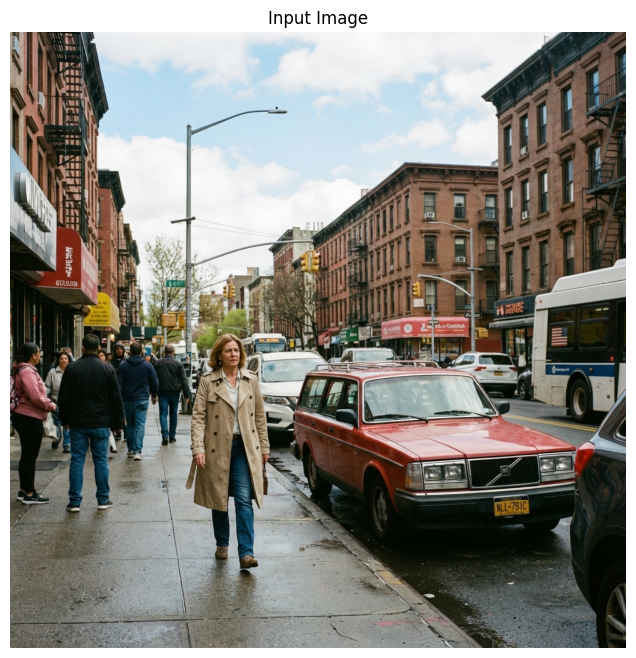

In [8]:
## 8. Load and Display Input Image
print(f"\nLoading image: {config['image_path']}")
img = cv2.imread(config["image_path"])
if img is None:
    print(f"❌ Error: Could not read image '{config['image_path']}'")
else:
    print(f"Image shape: {img.shape}")
    print(f"Image dtype: {img.dtype}")
    display_image(img, "Input Image")

In [9]:
## 9. Preprocess Image
print("\nPreprocessing image...")
original_img = img.copy()
input_tensor, ratio = preprocess(img, (config["input_size"], config["input_size"]))
print(f"Preprocessed input shape: {input_tensor.shape}")
print(f"Resize ratio: {ratio:.4f}")

# Display preprocessing steps (optional)
# You can add visualization of preprocessed image here


Preprocessing image...
Preprocessed input shape: (1, 3, 640, 640)
Resize ratio: 0.6250


In [10]:
## 10. Run Inference
print("\nRunning inference...")
import time
start_time = time.time()

results = compiled_model([input_tensor])
outputs = results[output_layer]

inference_time = (time.time() - start_time) * 1000
print(f"✓ Inference completed in {inference_time:.2f} ms")



Running inference...
✓ Inference completed in 125.14 ms


In [11]:
## 11. Postprocess Results
print("\nPostprocessing results...")
boxes, scores, class_ids = postprocess(
    outputs, 
    img.shape, 
    config["input_size"], 
    config["confidence_threshold"], 
    config["nms_threshold"], 
    ratio
)

if boxes is None or len(boxes) == 0:
    print("❌ No detections found!")
    output_img = original_img
else:
    print(f"✓ Detected {len(boxes)} objects:")
    
    # Print detection details
    print("\nDetection Details:")
    for i, (box, score, cls_id) in enumerate(zip(boxes, scores, class_ids)):
        x1, y1, x2, y2 = box.astype(int)
        class_name = COCO_CLASSES[int(cls_id)]
        print(f"  {i+1:2d}. {class_name:20s}: {score:.3f} at [{x1:4d}, {y1:4d}, {x2:4d}, {y2:4d}]")
    
    # Draw detections
    output_img = draw_detections(original_img.copy(), boxes, scores, class_ids)


Postprocessing results...
✓ Detected 25 objects:

Detection Details:
   1. person              : 0.937 at [ 295,  499,  434,  891]
   2. person              : 0.926 at [ 178,  516,  248,  710]
   3. person              : 0.915 at [  77,  506,  190,  799]
   4. person              : 0.910 at [   0,  514,   77,  786]
   5. person              : 0.895 at [ 237,  518,  295,  683]
   6. person              : 0.718 at [  55,  528,  102,  702]
   7. person              : 0.601 at [ 163,  517,  195,  563]
   8. person              : 0.274 at [ 714,  534,  735,  559]
   9. person              : 0.261 at [ 225,  531,  243,  556]
  10. car                 : 0.958 at [ 466,  552,  949,  849]
  11. car                 : 0.896 at [ 928,  587, 1023, 1006]
  12. car                 : 0.864 at [ 724,  531,  845,  609]
  13. car                 : 0.814 at [ 392,  527,  533,  674]
  14. car                 : 0.674 at [ 543,  523,  646,  553]
  15. car                 : 0.501 at [ 839,  555,  868,  610]



Displaying results...


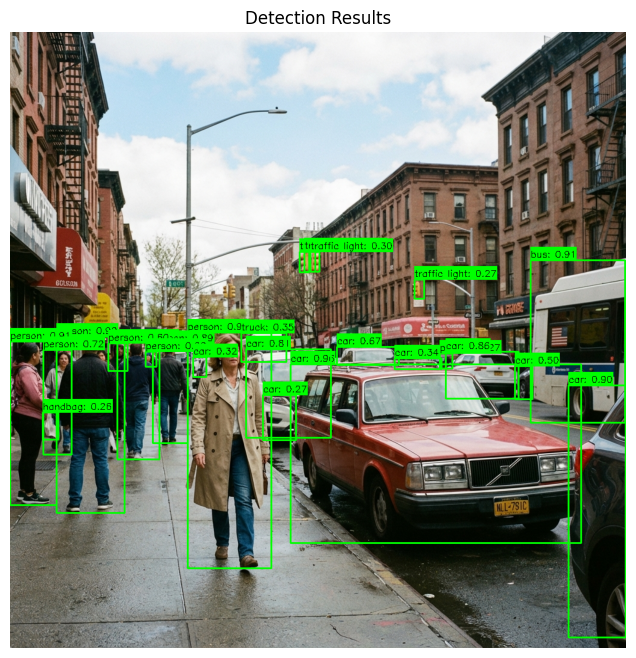

✓ Output saved to: output_openvino.jpg
✓ Output saved to: output_openvino.jpg


In [12]:
## 12. Display and Save Results
print("\nDisplaying results...")
display_image(output_img, "Detection Results")

# Save output image
cv2.imwrite(config["output_path"], output_img)
print(f"✓ Output saved to: {config['output_path']}")
# Save output image
cv2.imwrite(config["output_path"], output_img)
print(f"✓ Output saved to: {config['output_path']}")

In [13]:
## 13. Performance Metrics (Optional)
print("\nPerformance Metrics:")
print(f"  Inference time: {inference_time:.2f} ms")
if boxes is not None:
    print(f"  Objects detected: {len(boxes)}")
    print(f"  Average confidence: {np.mean(scores):.3f}")


Performance Metrics:
  Inference time: 125.14 ms
  Objects detected: 25
  Average confidence: 0.593
